# Career Progression and Promotion Gap Analysis

Palo Alto Networks HR extract. Goal is to look at promotion gaps / role stagnation instead of only predicting who quits.

Run from the project root so `data/Palo_Alto_Networks.csv` is on the path. Last cell writes `data/palo_alto_networks_scored.csv` for `app.py`.


## Setup


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, adjusted_rand_score
from scipy.cluster.hierarchy import dendrogram, linkage

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

DATA = Path("data") / "Palo_Alto_Networks.csv"
if not DATA.exists():
    raise FileNotFoundError(
        f"Could not find {DATA.resolve()}. Open the notebook from the project root."
    )

df = pd.read_csv(DATA)
print(df.shape)
df.head()


(1470, 24)


,EmployeeID,Age,Department,JobRole,EducationField,JobLevel,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,...,JobSatisfaction,EnvironmentSatisfaction,WorkLifeBalance,MonthlyIncome,DistanceFromHome,Gender,MaritalStatus,OverTime,NumCompaniesWorked,Attrition
0,1001,56,Research & Development,Healthcare Representative,Life Sciences,2,16,7,7,3,...,4,4,4,5640,8,Male,Married,Yes,7,1
1,1002,46,Sales,Sales Executive,Medical,3,22,14,11,0,...,2,4,2,10885,12,Female,Married,No,3,0
2,1003,32,Sales,Manager,Marketing,3,6,6,4,5,...,3,4,4,6661,19,Male,Divorced,No,0,0
3,1004,60,Research & Development,Laboratory Technician,Technical Degree,5,33,32,32,13,...,3,2,1,10788,12,Male,Married,No,5,1
4,1005,25,Research & Development,Healthcare Representative,Life Sciences,5,2,2,2,0,...,3,4,2,13714,22,Female,Married,Yes,7,1


In [2]:
df.info()
print("missing cells:", int(df.isna().sum().sum()))
print("duplicate rows:", int(df.duplicated().sum()))
df.describe().T


<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype
---  ------                   --------------  -----
 0   EmployeeID               1470 non-null   int64
 1   Age                      1470 non-null   int64
 2   Department               1470 non-null   str  
 3   JobRole                  1470 non-null   str  
 4   EducationField           1470 non-null   str  
 5   JobLevel                 1470 non-null   int64
 6   TotalWorkingYears        1470 non-null   int64
 7   YearsAtCompany           1470 non-null   int64
 8   YearsInCurrentRole       1470 non-null   int64
 9   YearsWithCurrManager     1470 non-null   int64
 10  YearsSinceLastPromotion  1470 non-null   int64
 11  TrainingTimesLastYear    1470 non-null   int64
 12  PercentSalaryHike        1470 non-null   int64
 13  PerformanceRating        1470 non-null   int64
 14  JobSatisfaction          1470 non-null   int64
 15  EnvironmentSati

,count,mean,std,min,25%,50%,75%,max
EmployeeID,1470.0,1735.500000,424.496761,1001.0,1368.25,1735.5,2102.75,2470.0
Age,1470.0,39.184354,12.335922,18.0,28.00,40.0,50.00,60.0
JobLevel,1470.0,2.261905,1.279829,1.0,1.00,2.0,3.00,5.0
TotalWorkingYears,1470.0,11.463265,8.306317,0.0,5.00,11.0,17.00,38.0
YearsAtCompany,1470.0,5.874150,5.961056,0.0,1.00,4.0,9.00,32.0
YearsInCurrentRole,1470.0,3.078231,4.120381,0.0,0.00,1.0,4.00,32.0
YearsWithCurrManager,1470.0,2.921769,3.946891,0.0,0.00,1.0,4.00,26.0
YearsSinceLastPromotion,1470.0,2.182993,3.011412,0.0,0.00,1.0,3.00,22.0
TrainingTimesLastYear,1470.0,3.051020,1.457165,0.0,2.00,3.0,4.00,6.0
PercentSalaryHike,1470.0,17.878912,4.350727,11.0,14.00,18.0,22.00,25.0


## EDA

Quick look at attrition, tenure, and years since last promotion before building ratios.


attrition rate: 20.4%
YearsAtCompany == 0: 201


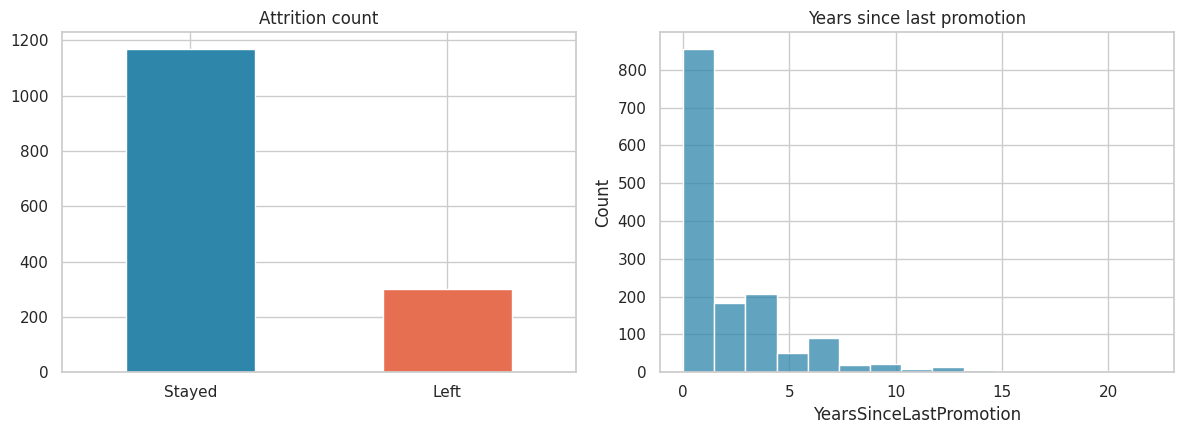

In [3]:
print(f"attrition rate: {df['Attrition'].mean()*100:.1f}%")
print("YearsAtCompany == 0:", int((df['YearsAtCompany'] == 0).sum()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
df["Attrition"].value_counts().rename({0: "Stayed", 1: "Left"}).plot(
    kind="bar", ax=axes[0], color=["#2E86AB", "#E76F51"]
)
axes[0].set_title("Attrition count")
axes[0].tick_params(axis="x", rotation=0)
axes[0].set_xlabel("")

sns.histplot(df["YearsSinceLastPromotion"], bins=15, ax=axes[1], color="#2E86AB")
axes[1].set_title("Years since last promotion")
plt.tight_layout()
plt.show()


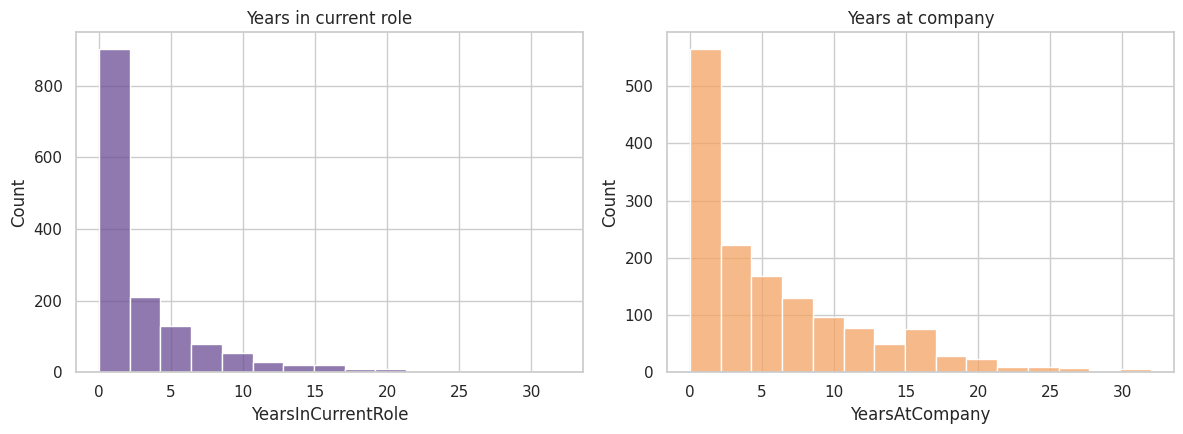

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
sns.histplot(df["YearsInCurrentRole"], bins=15, ax=axes[0], color="#6A4C93")
axes[0].set_title("Years in current role")
sns.histplot(df["YearsAtCompany"], bins=15, ax=axes[1], color="#F4A261")
axes[1].set_title("Years at company")
plt.tight_layout()
plt.show()


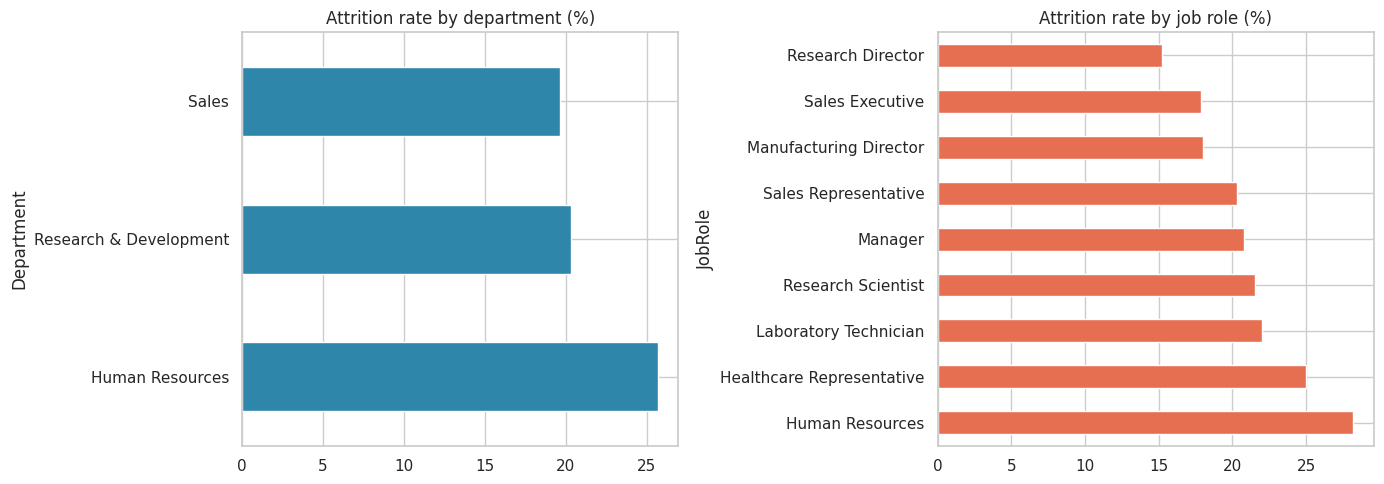

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

dept_attr = df.groupby("Department")["Attrition"].mean().sort_values(ascending=False) * 100
dept_attr.plot(kind="barh", ax=axes[0], color="#2E86AB")
axes[0].set_title("Attrition rate by department (%)")

role_attr = df.groupby("JobRole")["Attrition"].mean().sort_values(ascending=False) * 100
role_attr.plot(kind="barh", ax=axes[1], color="#E76F51")
axes[1].set_title("Attrition rate by job role (%)")
plt.tight_layout()
plt.show()


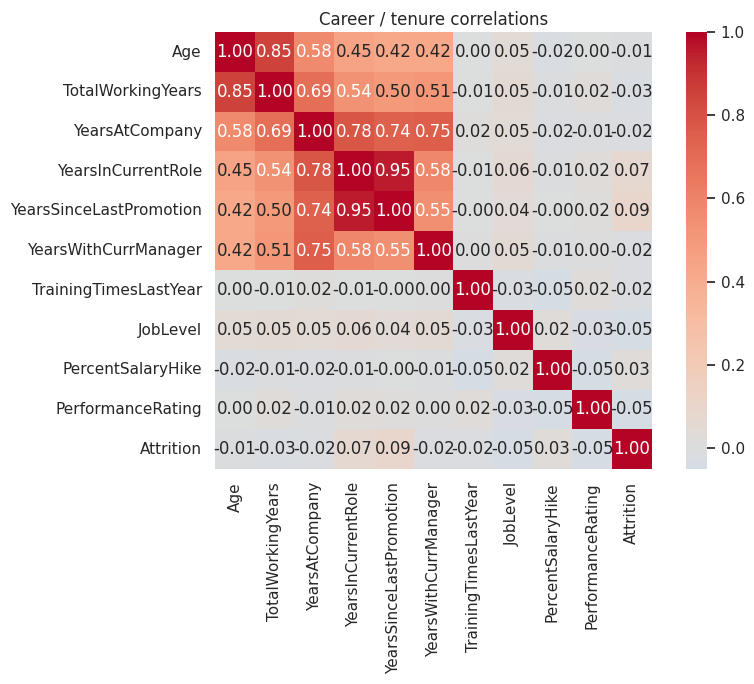

In [6]:
career_cols = [
    "Age", "TotalWorkingYears", "YearsAtCompany", "YearsInCurrentRole",
    "YearsSinceLastPromotion", "YearsWithCurrManager", "TrainingTimesLastYear",
    "JobLevel", "PercentSalaryHike", "PerformanceRating", "Attrition",
]

corr = df[career_cols].corr()
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Career / tenure correlations")
plt.tight_layout()
plt.show()


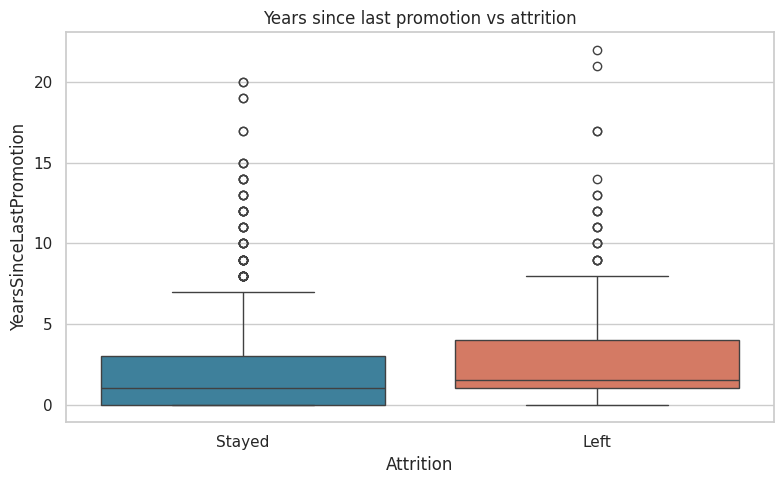

           YearsSinceLastPromotion  YearsInCurrentRole
Attrition                                             
0                         2.041880            2.932479
1                         2.733333            3.646667


In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=df, x="Attrition", y="YearsSinceLastPromotion",
    hue="Attrition", palette=["#2E86AB", "#E76F51"], ax=ax, legend=False,
)
ax.set_xticks([0, 1])
ax.set_xticklabels(["Stayed", "Left"])
ax.set_title("Years since last promotion vs attrition")
plt.tight_layout()
plt.show()

print(df.groupby("Attrition")[["YearsSinceLastPromotion", "YearsInCurrentRole"]].mean())


## Feature engineering

Raw tenure fields mostly track seniority, so we turn them into shares of time at the company.

- PromotionGapRatio = YearsSinceLastPromotion / YearsAtCompany
- RoleStagnationIndex = YearsInCurrentRole / YearsAtCompany
- TrainingIntensity = TrainingTimesLastYear / YearsAtCompany
- ManagerStability = YearsWithCurrManager / YearsAtCompany

`YearsAtCompany` is 0 for some new hires, so the denominator is at least 1. Gap / stagnation / manager ratios are clipped to [0, 1]. Training intensity is left unclipped because people can take more than one training per year of tenure.


In [8]:
work = df.copy()
denom = work["YearsAtCompany"].clip(lower=1)

work["PromotionGapRatio"] = work["YearsSinceLastPromotion"] / denom
work["RoleStagnationIndex"] = work["YearsInCurrentRole"] / denom
work["TrainingIntensity"] = work["TrainingTimesLastYear"] / denom
work["ManagerStability"] = work["YearsWithCurrManager"] / denom

for col in ["PromotionGapRatio", "RoleStagnationIndex", "ManagerStability"]:
    work[col] = work[col].clip(0, 1)

engineered = [
    "PromotionGapRatio", "RoleStagnationIndex",
    "TrainingIntensity", "ManagerStability",
]
work[engineered].describe()


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensity,ManagerStability
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.332364,0.447098,1.325659,0.432660
std,0.326504,0.388859,1.435751,0.393163
min,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.285714,0.000000
50%,0.285714,0.428571,0.732143,0.400000
75%,0.500000,0.833333,2.000000,0.800000
max,1.000000,1.000000,6.000000,1.000000


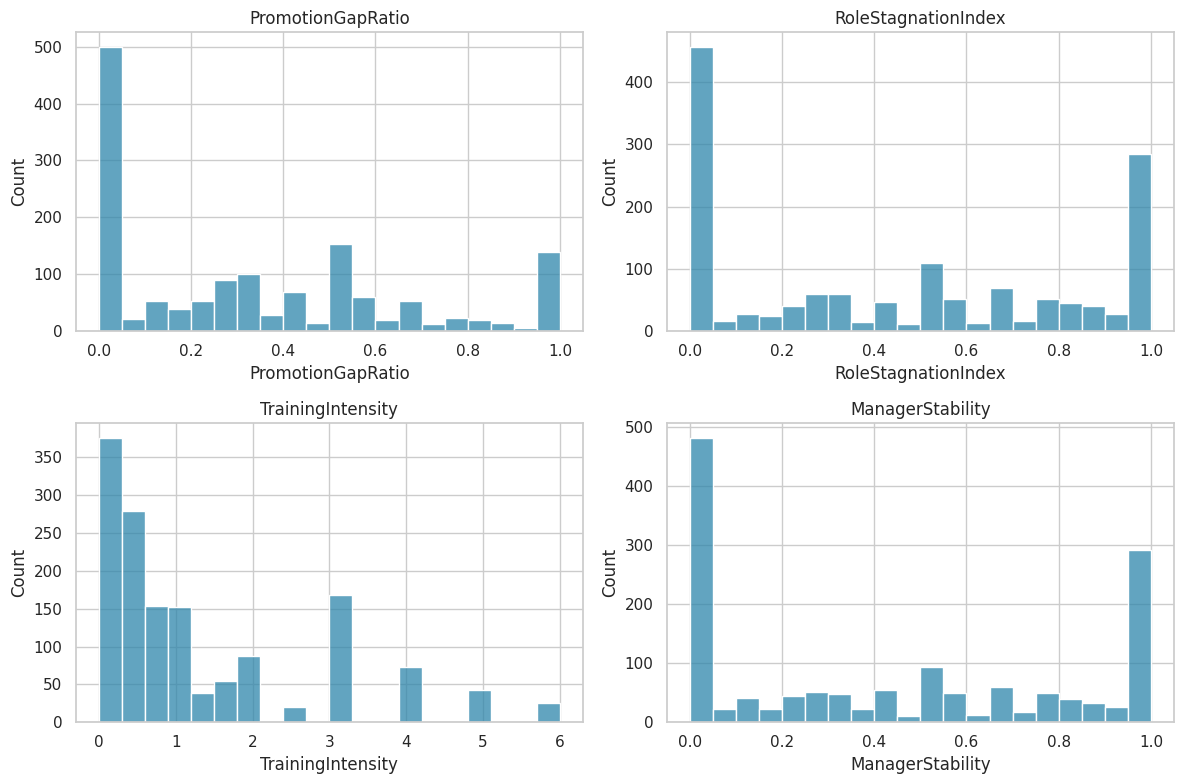

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col in zip(axes.flat, engineered):
    sns.histplot(work[col], bins=20, ax=ax, color="#2E86AB")
    ax.set_title(col)
plt.tight_layout()
plt.show()


## Preprocessing

Drop extreme TotalWorkingYears via IQR, encode department/role, scale the clustering matrix.

LabelEncoder is a bit crude for JobRole (it invents an order that isn't real) but it matches how the scored file was built, so we keep it.


In [10]:
before = len(work)
q1, q3 = work["TotalWorkingYears"].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
work = work[work["TotalWorkingYears"].between(low, high)].reset_index(drop=True)
print(f"dropped {before - len(work)} rows with TotalWorkingYears outside [{low:.1f}, {high:.1f}]")
print("n =", len(work))


dropped 5 rows with TotalWorkingYears outside [-13.0, 35.0]
n = 1465


In [11]:
le_dept = LabelEncoder()
le_role = LabelEncoder()
work["Department_enc"] = le_dept.fit_transform(work["Department"])
work["JobRole_enc"] = le_role.fit_transform(work["JobRole"])

cluster_features = engineered + ["Department_enc", "JobRole_enc"]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(work[cluster_features])
print(X_scaled.shape)


(1465, 6)


## Clustering

K-Means is the actual grouping. Elbow + silhouette for k. Hierarchical (Ward) is only there so we can check Adjusted Rand Index — if that is decent, the 4-group split isn't just a K-Means init artifact.


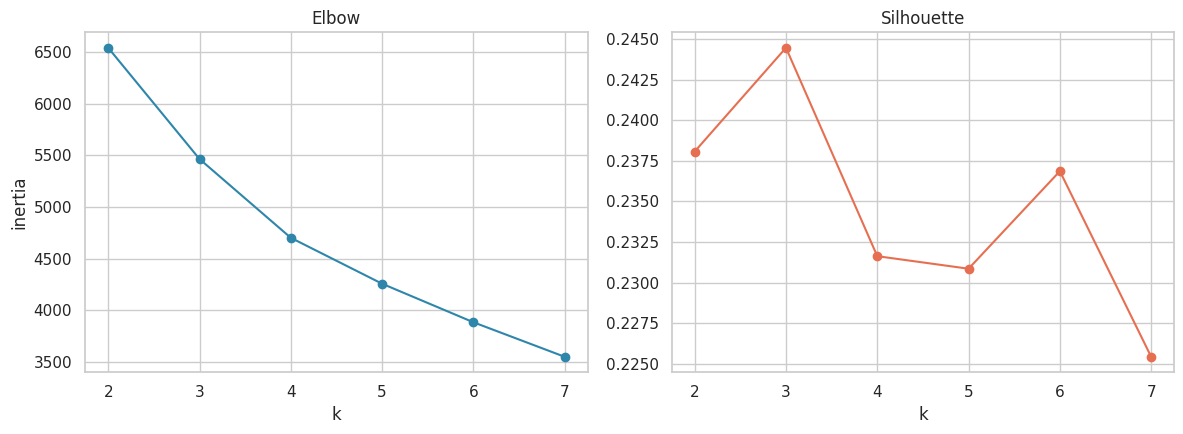

k=2: silhouette=0.238
k=3: silhouette=0.244
k=4: silhouette=0.232
k=5: silhouette=0.231
k=6: silhouette=0.237
k=7: silhouette=0.225


In [12]:
inertias, sil_scores = [], []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(list(k_range), inertias, marker="o", color="#2E86AB")
axes[0].set_title("Elbow")
axes[0].set_xlabel("k")
axes[0].set_ylabel("inertia")
axes[1].plot(list(k_range), sil_scores, marker="o", color="#E76F51")
axes[1].set_title("Silhouette")
axes[1].set_xlabel("k")
plt.tight_layout()
plt.show()

for k, s in zip(k_range, sil_scores):
    print(f"k={k}: silhouette={s:.3f}")


In [13]:
K_FINAL = 4  # k=4 was the compromise: silhouette prefers fewer groups, elbow still drops through 4

kmeans = KMeans(n_clusters=K_FINAL, random_state=42, n_init=10)
work["Cluster_KMeans"] = kmeans.fit_predict(X_scaled)
print(work["Cluster_KMeans"].value_counts().sort_index())


Cluster_KMeans
0    257
1    307
2    468
3    433
Name: count, dtype: int64


In [14]:
hier = AgglomerativeClustering(n_clusters=K_FINAL, linkage="ward")
work["Cluster_Hier"] = hier.fit_predict(X_scaled)
ari = adjusted_rand_score(work["Cluster_KMeans"], work["Cluster_Hier"])
print(f"ARI (K-Means vs Ward): {ari:.3f}")


ARI (K-Means vs Ward): 0.602


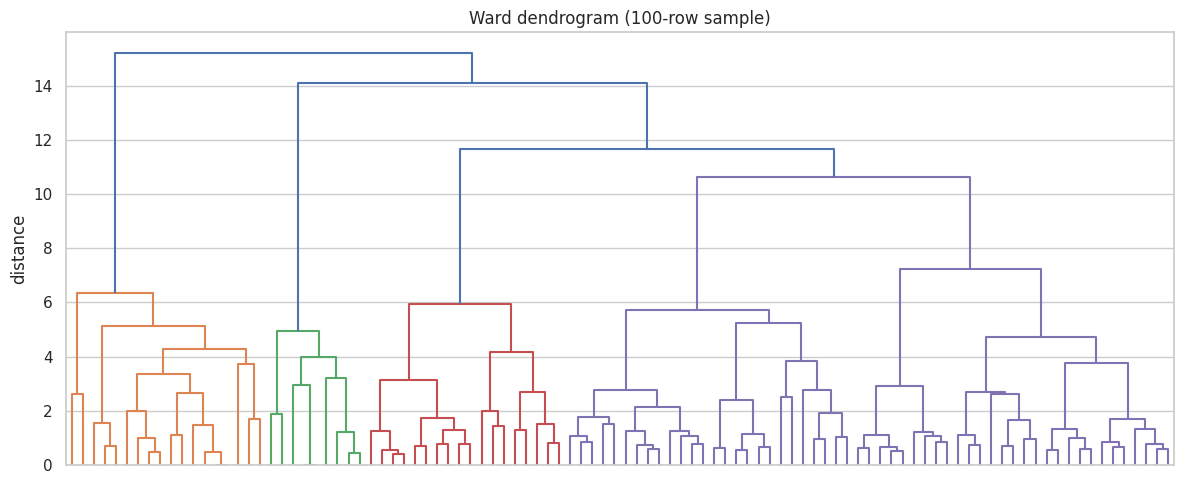

In [15]:
rng = np.random.RandomState(42)
sample_idx = rng.choice(len(X_scaled), size=min(100, len(X_scaled)), replace=False)
Z = linkage(X_scaled[sample_idx], method="ward")

plt.figure(figsize=(12, 5))
dendrogram(Z, no_labels=True)
plt.title("Ward dendrogram (100-row sample)")
plt.ylabel("distance")
plt.tight_layout()
plt.show()


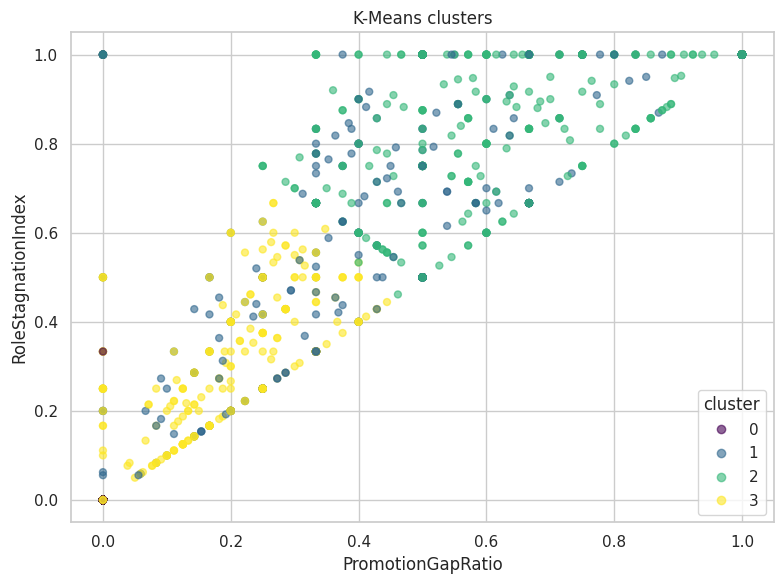

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
sc = ax.scatter(
    work["PromotionGapRatio"], work["RoleStagnationIndex"],
    c=work["Cluster_KMeans"], cmap="viridis", alpha=0.6, s=25,
)
ax.set_xlabel("PromotionGapRatio")
ax.set_ylabel("RoleStagnationIndex")
ax.set_title("K-Means clusters")
ax.legend(*sc.legend_elements(), title="cluster")
plt.tight_layout()
plt.show()


## Labels

K-Means ids are arbitrary. We name clusters from their mean ratios. If two numeric clusters look the same on those means they can share a label — that happened here (stable long-term ate the leftover group).


In [17]:
cluster_profile = work.groupby("Cluster_KMeans")[engineered + ["Attrition"]].mean().round(3)
cluster_profile["count"] = work["Cluster_KMeans"].value_counts().sort_index()
cluster_profile


,PromotionGapRatio,RoleStagnationIndex,TrainingIntensity,ManagerStability,Attrition,count
Cluster_KMeans,,,,,,
0,0.003,0.021,3.354,0.074,0.105,257
1,0.397,0.543,0.838,0.487,0.189,307
2,0.658,0.849,1.115,0.485,0.321,468
3,0.130,0.195,0.706,0.549,0.145,433


In [18]:
def label_cluster(row):
    if row["PromotionGapRatio"] < 0.3 and row["RoleStagnationIndex"] < 0.3:
        return "Fast-track performers"
    if row["PromotionGapRatio"] > 0.6 and row["RoleStagnationIndex"] > 0.6:
        return "High-risk stagnation profiles"
    train_cut = cluster_profile["TrainingIntensity"].median()
    if row["TrainingIntensity"] > train_cut:
        return "Early-career explorers"
    return "Stable long-term contributors"

cluster_labels = cluster_profile.apply(label_cluster, axis=1)
print(cluster_labels)

work["CareerCluster"] = work["Cluster_KMeans"].map(cluster_labels.to_dict())
work["CareerCluster"].value_counts()


Cluster_KMeans
0            Fast-track performers
1    Stable long-term contributors
2    High-risk stagnation profiles
3            Fast-track performers
dtype: str


CareerCluster
Fast-track performers            690
High-risk stagnation profiles    468
Stable long-term contributors    307
Name: count, dtype: int64

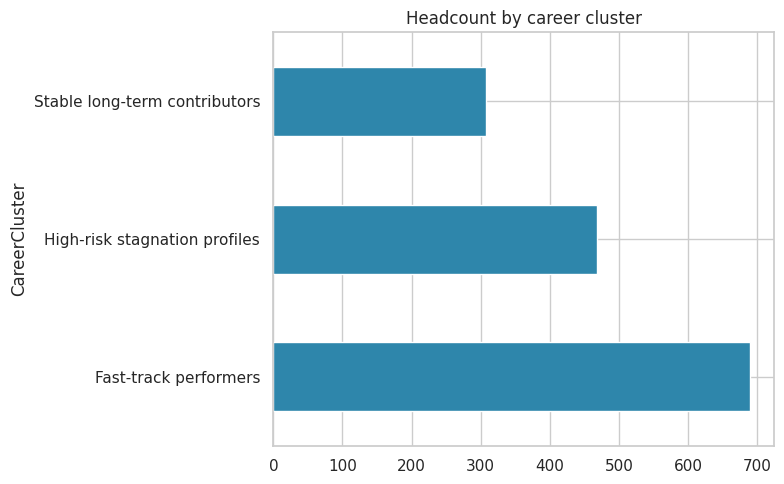

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
work["CareerCluster"].value_counts().plot(kind="barh", ax=ax, color="#2E86AB")
ax.set_title("Headcount by career cluster")
plt.tight_layout()
plt.show()


## Promotion gap score

Composite = 0.4 gap + 0.4 role stagnation + 0.1 *(1 - clipped training)* + 0.1 manager stability.

Terciles become Low / Medium / High. This is a stagnation score, not an attrition probability — Low-gap people in this extract actually attrit more.


In [20]:
work["StagnationComposite"] = (
    work["PromotionGapRatio"] * 0.4
    + work["RoleStagnationIndex"] * 0.4
    + (1 - work["TrainingIntensity"].clip(0, 1)) * 0.1
    + work["ManagerStability"] * 0.1
)

q_low, q_high = work["StagnationComposite"].quantile([0.33, 0.67])

def risk_bucket(score):
    if score <= q_low:
        return "Low"
    if score <= q_high:
        return "Medium"
    return "High"

work["PromotionGapScore"] = work["StagnationComposite"].apply(risk_bucket)
print(work["PromotionGapScore"].value_counts())
print("cuts:", round(q_low, 3), round(q_high, 3))


PromotionGapScore
Medium    497
High      484
Low       484
Name: count, dtype: int64
cuts: 0.188 0.56


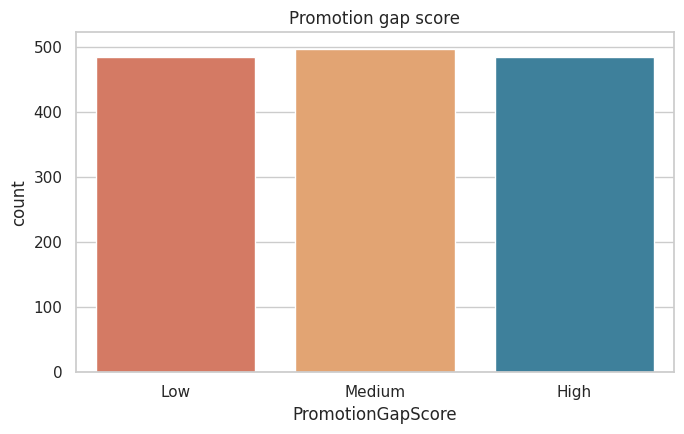

CareerCluster,Fast-track performers,High-risk stagnation profiles,Stable long-term contributors
PromotionGapScore,,,
High,0,366,118
Low,436,0,48
Medium,254,102,141


In [21]:
fig, ax = plt.subplots(figsize=(7, 4.5))
order = ["Low", "Medium", "High"]
sns.countplot(
    data=work, x="PromotionGapScore", order=order, hue="PromotionGapScore",
    palette=["#2E86AB", "#F4A261", "#E76F51"], ax=ax, legend=False,
)
ax.set_title("Promotion gap score")
plt.tight_layout()
plt.show()

pd.crosstab(work["PromotionGapScore"], work["CareerCluster"])


## Retention opportunity

Still at the company, Medium or High gap score, JobSatisfaction not 1. That's the group where a career conversation still has something to work with.


In [22]:
work["RetentionOpportunity"] = (
    (work["Attrition"] == 0)
    & work["PromotionGapScore"].isin(["Medium", "High"])
    & (work["JobSatisfaction"] >= 2)
)

n_opportunity = int(work["RetentionOpportunity"].sum())
print(f"{n_opportunity} employees ({n_opportunity / len(work) * 100:.1f}%)")

work.loc[
    work["RetentionOpportunity"],
    ["Department", "JobRole", "CareerCluster", "PromotionGapScore",
     "YearsSinceLastPromotion", "YearsInCurrentRole"],
].head(10)


649 employees (44.3%)


,Department,JobRole,CareerCluster,PromotionGapScore,YearsSinceLastPromotion,YearsInCurrentRole
1,Sales,Sales Executive,Stable long-term contributors,High,7,11
2,Sales,Manager,Stable long-term contributors,High,3,4
5,Research & Development,Manager,Fast-track performers,Medium,4,5
6,Sales,Sales Representative,Stable long-term contributors,High,4,4
12,Human Resources,Manager,High-risk stagnation profiles,High,9,11
13,Research & Development,Research Scientist,High-risk stagnation profiles,High,5,6
15,Research & Development,Research Scientist,High-risk stagnation profiles,Medium,0,1
18,Sales,Sales Representative,Stable long-term contributors,High,5,8
20,Sales,Sales Representative,Stable long-term contributors,High,20,20
22,Research & Development,Manager,High-risk stagnation profiles,High,6,9


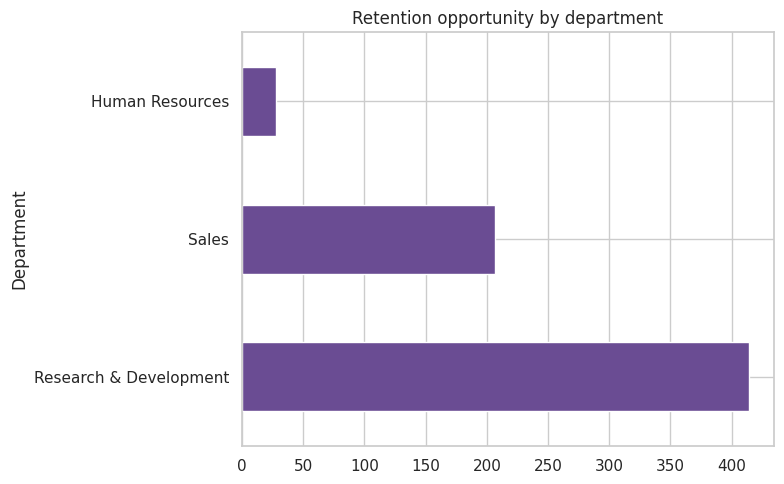

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))
work.loc[work["RetentionOpportunity"], "Department"].value_counts().plot(
    kind="barh", ax=ax, color="#6A4C93"
)
ax.set_title("Retention opportunity by department")
plt.tight_layout()
plt.show()


## KPI snapshot


In [24]:
mgr_bin = pd.cut(
    work["ManagerStability"],
    bins=[-0.01, 0.33, 0.67, 1.0],
    labels=["Low", "Medium", "High"],
)
manager_stability_impact = work.groupby(mgr_bin, observed=True)["Attrition"].mean() * 100

kpi_summary = pd.DataFrame({
    "KPI": [
        "Career cluster",
        "Promotion gap score",
        "Retention opportunity",
        "Training intensity",
        "Manager stability",
    ],
    "Reading": [
        f"largest group: {work['CareerCluster'].value_counts().idxmax()}",
        f"{(work['PromotionGapScore']=='High').mean()*100:.1f}% High",
        f"{n_opportunity} people ({n_opportunity/len(work)*100:.1f}%)",
        f"{(work['TrainingIntensity'] < work['TrainingIntensity'].median()).mean()*100:.1f}% below median",
        f"Low mgr stability attrition {manager_stability_impact.get('Low', float('nan')):.1f}% vs "
        f"High {manager_stability_impact.get('High', float('nan')):.1f}%",
    ],
})
kpi_summary


,KPI,Reading
0,Career cluster,largest group: Fast-track performers
1,Promotion gap score,33.0% High
2,Retention opportunity,649 people (44.3%)
3,Training intensity,49.9% below median
4,Manager stability,Low mgr stability attrition 20.4% vs High 21.2%


## Export


In [25]:
out_cols = list(df.columns) + engineered + [
    "CareerCluster", "PromotionGapScore", "StagnationComposite", "RetentionOpportunity",
]
out_path = Path("data") / "palo_alto_networks_scored.csv"
export_df = work[out_cols]
export_df.to_csv(out_path, index=False)
print(f"wrote {export_df.shape} -> {out_path}")
export_df.head()


wrote (1465, 32) -> data/palo_alto_networks_scored.csv


,EmployeeID,Age,Department,JobRole,EducationField,JobLevel,TotalWorkingYears,YearsAtCompany,YearsInCurrentRole,YearsWithCurrManager,...,NumCompaniesWorked,Attrition,PromotionGapRatio,RoleStagnationIndex,TrainingIntensity,ManagerStability,CareerCluster,PromotionGapScore,StagnationComposite,RetentionOpportunity
0,1001,56,Research & Development,Healthcare Representative,Life Sciences,2,16,7,7,3,...,7,1,0.714286,1.000000,0.428571,0.428571,High-risk stagnation profiles,High,0.785714,False
1,1002,46,Sales,Sales Executive,Medical,3,22,14,11,0,...,3,0,0.500000,0.785714,0.214286,0.000000,Stable long-term contributors,High,0.592857,True
2,1003,32,Sales,Manager,Marketing,3,6,6,4,5,...,0,0,0.500000,0.666667,0.333333,0.833333,Stable long-term contributors,High,0.616667,True
3,1004,60,Research & Development,Laboratory Technician,Technical Degree,5,33,32,32,13,...,5,1,0.656250,1.000000,0.125000,0.406250,High-risk stagnation profiles,High,0.790625,False
4,1005,25,Research & Development,Healthcare Representative,Life Sciences,5,2,2,2,0,...,7,1,0.500000,1.000000,1.500000,0.000000,High-risk stagnation profiles,High,0.600000,False
